In [15]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize
from skimage import data, io, color, transform, exposure, filters, util
from skimage.morphology import disk, opening, closing
import cv2
from torchvision import datasets

# print(np.__version__, cv2.__version__)

In [2]:
mnist = datasets.MNIST(root='../data', train=False, download=False)
image, label = mnist[0]
arr = np.array(image)
print('shape:', arr.shape, 'dtype:', arr.dtype, 'min:', arr.min(), 'max:', arr.max())

shape: (28, 28) dtype: uint8 min: 0 max: 255


C:\Users\35314\miniconda3\envs\pytorch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [64..4095].


shape: (16, 512, 512, 3) dtype: uint16 min: 10 max: 4095


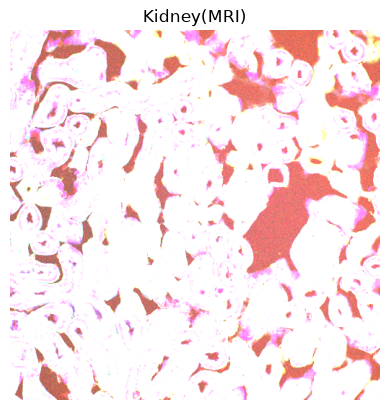

In [3]:
mri = data.kidney()
print('shape:', mri.shape, 'dtype:', mri.dtype, 'min:', mri.min(), 'max:', mri.max())
slice_2d = mri[8]

# --- 显示前先看四个值：shape / dtype / min / max ---
# 这里的结果是 (16, 512, 512, 3) uint16，min=10，max=4095，含义有三层：
#   1) 最后一维是 3 -> 每个切片是三通道(RGB)，matplotlib 按彩色图处理，cmap='gray' 会被忽略；
#   2) 4095 = 2**12 - 1 -> 这是 12 位数据，不是常见的 8 位(0~255)；
#   3) 三通道数据 matplotlib 不做自动缩放，只认 0~1(float) 或 0~255(整数)，超出的会被截断成 255。
# 所以下面这张图大部分像素被压成纯白，看着像'什么都没有'。完整原理见本文件末尾的 markdown 说明。
plt.imshow(slice_2d, cmap='gray')
plt.title("Kidney(MRI)")
plt.axis("off")
plt.show()

In [4]:
print([n for n in dir(data) if not n.startswith("_")])

['astronaut', 'binary_blobs', 'brain', 'brick', 'camera', 'cat', 'cell', 'cells3d', 'checkerboard', 'chelsea', 'clock', 'coffee', 'coins', 'colorwheel', 'data_dir', 'download_all', 'eagle', 'file_hash', 'grass', 'gravel', 'horse', 'hubble_deep_field', 'human_mitosis', 'immunohistochemistry', 'kidney', 'lbp_frontal_face_cascade_filename', 'lfw_subset', 'lily', 'logo', 'microaneurysms', 'moon', 'nickel_solidification', 'page', 'palisades_of_vogt', 'protein_transport', 'retina', 'rocket', 'shepp_logan_phantom', 'skin', 'stereo_motorcycle', 'text', 'vortex']


(512, 512, 3) uint8
和原图一样吗？ True


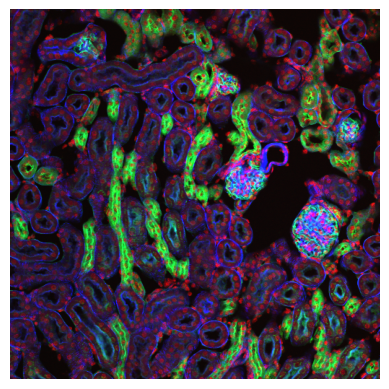

In [5]:
# 把数值换算到 matplotlib 认的刻度：先除以本切片最大值(变成 0~1)，再乘 255(变成 0~255)。
# 注意：这只是线性拉伸(min-max 归一化)，像素之间的相对亮暗关系没变，变的只是显示的刻度。
# 别和 util.img_as_ubyte 搞混：它按 dtype 的满量程(uint16 对 65535)换算，4095 会变成 15，图会几乎全黑。
slice_u8 = (slice_2d / slice_2d.max() * 255).astype(np.uint8)
io.imsave("outputs/kidney.png", slice_u8)
back = io.imread("outputs/kidney.png")
plt.imshow(back, cmap='gray')
plt.axis("off")
print(back.shape, back.dtype)
print("和原图一样吗？", np.array_equal(slice_u8, back))

shape: (1411, 1411, 3) dtype: uint8 min: 0 max: 255
shape: (1411, 1411) dtype: float64 min: 0.0 max: 0.9229600000000001
shape: (1411, 1411) dtype: uint8 min: 0 max: 235


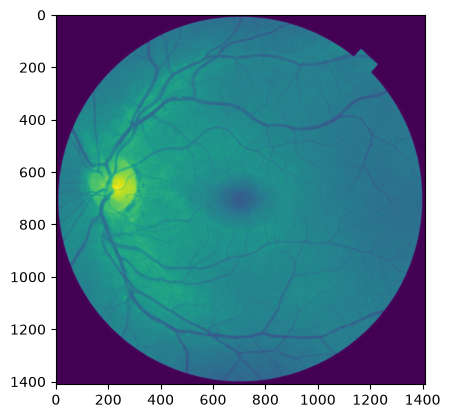

In [6]:
# 转换为灰度图
retina = data.retina()
print('shape:', retina.shape, 'dtype:', retina.dtype, 'min:', retina.min(), 'max:', retina.max())
gray_float = color.rgb2gray(retina)
gray_byte = util.img_as_ubyte(gray_float)
print('shape:', gray_float.shape, 'dtype:', gray_float.dtype, 'min:', gray_float.min(), 'max:', gray_float.max())
print('shape:', gray_byte.shape, 'dtype:', gray_byte.dtype, 'min:', gray_byte.min(), 'max:', gray_byte.max())
plt.imshow(gray_byte)

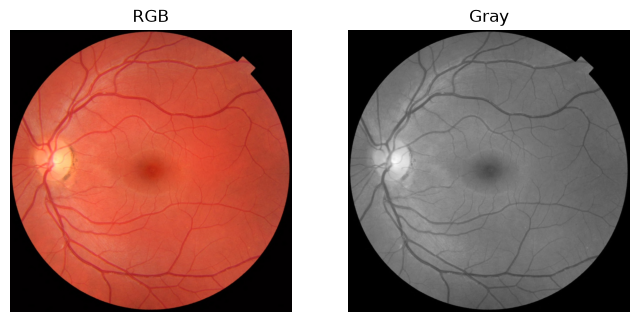

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(retina)
axes[0].set_title("RGB")
axes[1].imshow(gray_byte, cmap="gray")
axes[1].set_title("Gray")
for ax in axes: ax.axis("off")
plt.savefig("outputs/01_gray_compare.png", dpi=120, bbox_inches='tight')
plt.show()

原图大小: (512, 512, 3) uint8 缩小后: (128, 128, 3) uint8


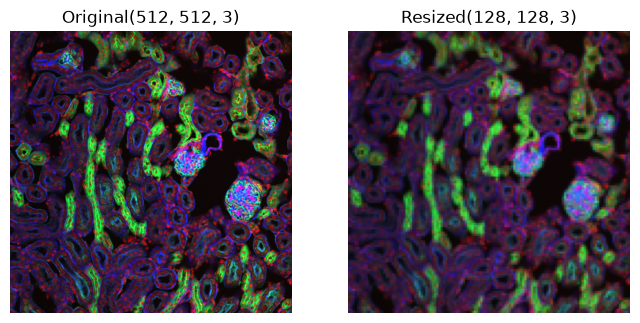

In [8]:
# 缩放
small = transform.resize(slice_u8, (128, 128), anti_aliasing=True)
small = (small * 255).astype(np.uint8)
print("原图大小:", slice_u8.shape, slice_u8.dtype, "缩小后:", small.shape, small.dtype)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(slice_u8, cmap="gray")
axes[0].set_title(f"Original{slice_u8.shape}")
axes[1].imshow(small, cmap="gray")
axes[1].set_title(f"Resized{small.shape}")
for ax in axes: ax.axis("off")
plt.savefig("outputs/02_resize_compare.png", dpi=120, bbox_inches='tight')
plt.show()

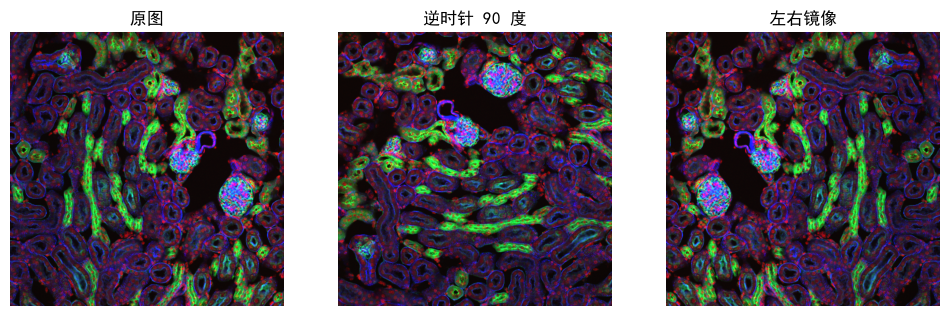

In [9]:
# 旋转与翻转
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows 用黑体
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号
rot = transform.rotate(slice_u8, 90)
flip = np.fliplr(slice_u8)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(slice_u8, cmap="gray");  axes[0].set_title("原图")
axes[1].imshow(rot, cmap="gray");  axes[1].set_title("逆时针 90 度")
axes[2].imshow(flip, cmap="gray"); axes[2].set_title("左右镜像")
for ax in axes: ax.axis("off")
plt.savefig("outputs/03_geometry.png", dpi=120, bbox_inches="tight")
plt.show()

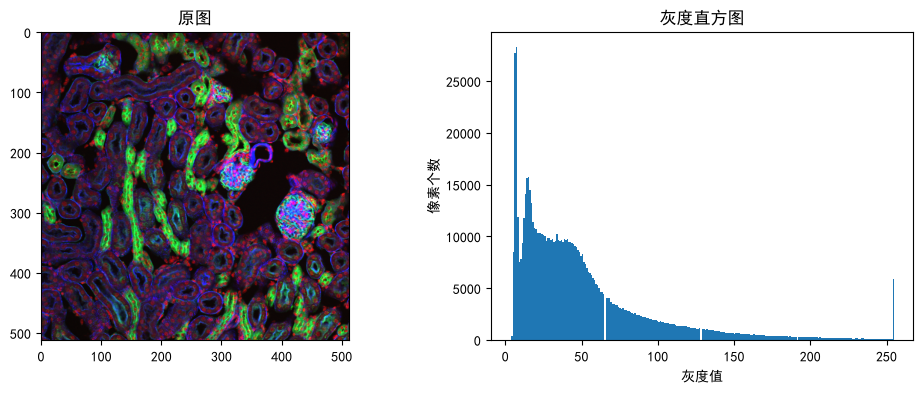

In [10]:
# 直方图
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(slice_u8, cmap="gray"); axes[0].set_title("原图")
axes[1].hist(slice_u8.ravel(), bins=256)
axes[1].set_title("灰度直方图")
axes[1].set_xlabel("灰度值")
axes[1].set_ylabel("像素个数")
plt.savefig("outputs/04_histogram.png", dpi=120, bbox_inches="tight")
plt.show()

均衡后取值范围: 1.2715657552083333e-06 1.0


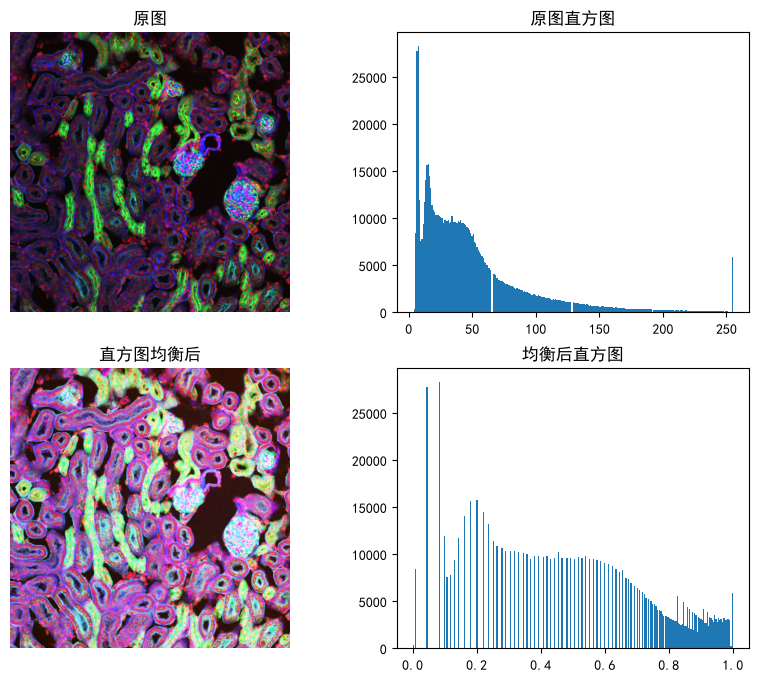

In [12]:
# 直方图均衡
eq = exposure.equalize_hist(slice_u8)
print("均衡后取值范围:", eq.min(), eq.max())
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].imshow(slice_u8, cmap="gray"); axes[0, 0].set_title("原图")
axes[0, 1].hist(slice_u8.ravel(), bins=256); axes[0, 1].set_title("原图直方图")
axes[1, 0].imshow(eq, cmap="gray"); axes[1, 0].set_title("直方图均衡后")
axes[1, 1].hist(eq.ravel(), bins=256);axes[1, 1].set_title("均衡后直方图")
for ax in (axes[0, 0], axes[1, 0]): ax.axis("off")
plt.savefig("outputs/05_equalize.png", dpi=120, bbox_inches="tight")
plt.show()


threshold: 38 目标像素占比: 0.11360549926757812


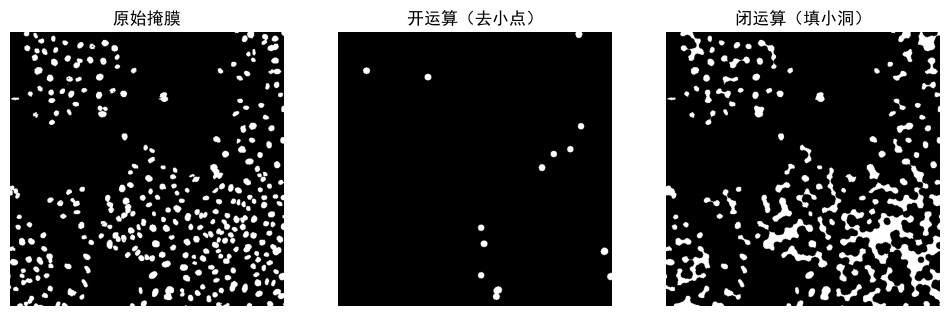

In [20]:
# 形态学操作
cells = data.human_mitosis()
thresh = filters.threshold_otsu(cells)
mask = cells > thresh
print("threshold:", thresh, "目标像素占比:", mask.mean())
kernel = disk(6)
opened = opening(mask, kernel)
closed = closing(mask, kernel)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(mask, cmap="gray");   axes[0].set_title("原始掩膜")
axes[1].imshow(opened, cmap="gray"); axes[1].set_title("开运算（去小点）")
axes[2].imshow(closed, cmap="gray"); axes[2].set_title("闭运算（填小洞）")
for ax in axes: ax.axis("off")
plt.savefig("outputs/06_morphology.png", dpi=120, bbox_inches="tight")
plt.show()